
<div style="
  background: linear-gradient(135deg, #ff9a9e, #fad0c4, #fbc2eb);
  padding: 28px;
  border-radius: 24px;
  text-align: center;
  color: #3a2c4a;
  box-shadow: 0 8px 20px rgba(0,0,0,0.12);
">

  <h1 style="font-size: 42px; margin-bottom: 8px;">
    🌈 DaneshChat AI Adventure 🚀
  </h1>

  <h2 style="font-size: 24px; margin-top: 0;">
    Build Smart Models for Spam & Message Loss Detection
  </h2>


</div>

### Imports

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load the dataset

In [41]:
df = pd.read_csv('datasets/daneshchat_logs.csv')
print(df.head())

   message_size_kb  transfer_steps  connection_quality  has_urgent_keyword  \
0            49.73              10               0.954                   0   
1            60.27               4               0.369                   0   
2            77.18              17               0.025                   0   
3            21.13               8               0.334                   1   
4            39.09               2               0.664                   0   

   has_link  is_spam  is_lost  
0         0        0        0  
1         0        0        1  
2         0        0        1  
3         0        1        1  
4         0        0        0  


### Quick data check

In [42]:
print(df)
print("-" * 100)
print(df.columns)
print("-" * 100)
print(df.isnull().sum())
print("-" * 100)
print(df.describe())

      message_size_kb  transfer_steps  connection_quality  has_urgent_keyword  \
0               49.73              10               0.954                   0   
1               60.27               4               0.369                   0   
2               77.18              17               0.025                   0   
3               21.13               8               0.334                   1   
4               39.09               2               0.664                   0   
...               ...             ...                 ...                 ...   
5995            34.49               4               0.786                   0   
5996            37.11               5               0.690                   0   
5997           197.17              16               0.182                   0   
5998            51.93               4               0.561                   0   
5999            54.80              18               0.742                   0   

      has_link  is_spam  is

### Clean the dataset

In [43]:
df.drop_duplicates(inplace = True)
for col in df.columns:
    df[col] = pd.to_numeric(df[col] , errors = 'coerce')
df.dropna(inplace = True)
df = df[(df['connection_quality'] >=0) & (df['connection_quality'] <= 1)]
df = df[(df['message_size_kb'] > 0) & (df['transfer_steps'] > 0)]

<div style="
  background: linear-gradient(135deg, #74c69d, #48cae4);
  padding: 26px;
  border-radius: 22px;
  margin-top: 28px;
  border: 4px solid #2d6a4f;
  box-shadow: 0 8px 22px rgba(0, 0, 0, 0.18);
  color: #081c15;
">

  <h1 style="
    color: #081c15;
    background-color: rgba(255, 255, 255, 0.65);
    padding: 12px 16px;
    border-radius: 14px;
    margin-top: 0;
  ">
    🌳 Part A: Build a Decision Tree from Scratch
  </h1>

  <p style="
    font-size: 17px;
    line-height: 1.7;
    color: #133f30;
    font-weight: 500;
  ">
    In this part, you will build your own Decision Tree classifier.
    You may use Python, NumPy, and Pandas, but not a ready-made Decision Tree model.
  </p>

  <pre style="
    background-color: #0f4331;
    color: #d8f3dc;
    padding: 16px;
    border-radius: 14px;
    border: 3px solid #95d5b2;
    font-size: 15px;
    line-height: 1.6;
    overflow-x: auto;
  ">Is connection_quality <= 0.45?

├── Yes: maybe lost

└── No: maybe delivered</pre>

</div>

### Create a Node class

In [44]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold= threshold
        self.left= left
        self.right= right
        self.value = value
      
    
    def is_leaf(self):
        return self.value is not None


### Decision Tree Classifier from Scratch

In [45]:
class DecisionTreeClassifierScratch:
    def __init__(self, max_depth=5, min_samples_split=20, min_samples_leaf=10):
        self.max_depth = max_depth
        
        self.min_samples_split = min_samples_split
        
        self.min_samples_leaf = min_samples_leaf
        
        self.root = None

    def entropy(self, y):
        values, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return -np.sum([p * np.log2(p) for p in probabilities if p > 0])

    def information_gain(self, y, y_left, y_right):
        parent_entropy = self.entropy(y)
        
        n = len(y)
        n_l, n_r = len(y_left), len(y_right)
        
        if n_l == 0 or n_r == 0:
            return 0
            
        child_entropy = (n_l / n) * self.entropy(y_left) + (n_r / n) * self.entropy(y_right)
        
        return parent_entropy - child_entropy

    def majority_class(self, y):
        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]

    def find_best_split(self, X, y):
        best_gain = -1
        best_feature = None
        best_threshold = None
        n_features = X.shape[1]

        # TODO: Try each feature
        for feature_idx in range(n_features):
            X_column = X[:, feature_idx]
            
            thresholds = np.unique(X_column)
            for threshold in thresholds:
                left_mask = X_column <= threshold
                right_mask = X_column > threshold
                
                y_left = y[left_mask]
                y_right = y[right_mask]

                if len(y_left) < self.min_samples_leaf or len(y_right) < self.min_samples_leaf:
                    continue

                gain = self.information_gain(y, y_left, y_right)

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold

        return best_feature, best_threshold

    def build_tree(self, X, y, depth=0):
        n_samples = X.shape[0]
        n_classes = len(np.unique(y))

        if (depth >= self.max_depth or 
            n_classes == 1 or 
            n_samples < self.min_samples_split):
            leaf_value = self.majority_class(y)
            return Node(value=leaf_value)

        best_feature, best_threshold = self.find_best_split(X, y)

        if best_feature is None:
            leaf_value = self.majority_class(y)
            return Node(value=leaf_value)

        left_mask = X[:, best_feature] <= best_threshold
        right_mask = X[:, best_feature] > best_threshold

        left_child = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self.build_tree(X[right_mask], y[right_mask], depth + 1)

        return Node(feature=best_feature, threshold=best_threshold, left=left_child, right=right_child)

    def fit(self, X, y):
        if isinstance(X, pd.DataFrame): X = X.values
        if isinstance(y, pd.Series): y = y.values
            
        self.root = self.build_tree(X, y, depth=0)

    def predict_one(self, row, node):
        if node.is_leaf():
            return node.value
            
        if row[node.feature] <= node.threshold:
            return self.predict_one(row, node.left)
        return self.predict_one(row, node.right)

    def predict(self, X):
        if isinstance(X, pd.DataFrame): X = X.values
        return np.array([self.predict_one(row, self.root) for row in X])

### Prepare data for spam prediction

In [46]:
from sklearn.model_selection import train_test_split

y_spam = df["is_spam"]
X_spam = df.drop(columns=["is_spam", "is_lost"])
X_train_spam, X_val_spam, y_train_spam, y_val_spam = train_test_split(
    X_spam, y_spam, test_size=0.2, random_state=42
)

### Train your scratch Decision Tree for spam

In [47]:
dt_model = DecisionTreeClassifierScratch(max_depth=5, min_samples_split=20, min_samples_leaf=10)
dt_model.fit(X_train_spam, y_train_spam)
y_pred_spam = dt_model.predict(X_val_spam)

### Create an evaluation function

In [48]:
def evaluate_model(y_true, y_pred, model_name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    accuracy = (tp + tn) / len(y_true)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    print(f" --- {model_name} Evaluation Results ---")
    print(f" Accuracy:  {accuracy:.4f}")
    print(f" Precision: {precision:.4f}")
    print(f" Recall:    {recall:.4f}")
    print(f" F1-Score:  {f1_score:.4f}")
    print("-" * 35)

evaluate_model(y_val_spam, y_pred_spam, "Scratch Decision Tree (Spam)")

 --- Scratch Decision Tree (Spam) Evaluation Results ---
 Accuracy:  0.6800
 Precision: 0.7292
 Recall:    0.4447
 F1-Score:  0.5524
-----------------------------------


<div style="
  background: linear-gradient(135deg, #e8b7e8, #ffb6f4);
  padding: 24px;
  border-radius: 22px;
  margin-top: 28px;
  border: 4px solid #481344;
  color: #2b0a2a;
">

  <h1 style="color: #2b0a2a;">⚡ Part B: Fast Spam Filtering with Scikit-learn</h1>

  <p style="font-size: 17px; line-height: 1.7; color: #2b0a2a;">
    Now you can use ready-made tools from Scikit-learn.
    In this part, focus only on predicting <code>is_spam</code>.
  </p>

</div>

### Train a Naive Bayes spam filter

In [49]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score

nb_model = GaussianNB()

nb_model.fit(X_train_spam, y_train_spam)

y_pred_nb = nb_model.predict(X_val_spam)

acc_nb = accuracy_score(y_val_spam, y_pred_nb)
f1_nb = f1_score(y_val_spam, y_pred_nb)

print(f"Naive Bayes - Accuracy: {acc_nb:.4f}")
print(f"Naive Bayes - F1-score: {f1_nb:.4f}")

Naive Bayes - Accuracy: 0.6750
Naive Bayes - F1-score: 0.5113


### Random Forest and GridSearchCV

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_model = RandomForestClassifier(random_state=42)

param_grid = {'max_depth': [3, 5, 10, None]}

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, scoring='f1', cv=5)

grid_search.fit(X_train_spam, y_train_spam)

print(f"Best parameters found: {grid_search.best_params_}")

best_rf_model = grid_search.best_estimator_
y_pred_rf = best_rf_model.predict(X_val_spam)

acc_rf = accuracy_score(y_val_spam, y_pred_rf)
f1_rf = f1_score(y_val_spam, y_pred_rf)

print(f"Random Forest (Tuned) - Accuracy: {acc_rf:.4f}")
print(f"Random Forest (Tuned) - F1-score: {f1_rf:.4f}")

Best parameters found: {'max_depth': None}
Random Forest (Tuned) - Accuracy: 0.6150
Random Forest (Tuned) - F1-score: 0.5188


### Final model comparison

In [51]:
acc_scratch = 0.6800
f1_scratch = 0.5524

comparison_data = {
    "Model": ["Scratch Decision Tree", "Naive Bayes", "Random Forest"],
    "Accuracy": [acc_scratch, acc_nb, acc_rf],
    "F1-score": [f1_scratch, f1_nb, f1_rf]
}
df_comparison = pd.DataFrame(comparison_data)

display(df_comparison)


,Model,Accuracy,F1-score
0,Scratch Decision Tree,0.680,0.552400
1,Naive Bayes,0.675,0.511278
2,Random Forest,0.615,0.518750


<div style="
  background: linear-gradient(135deg, #9668b1, #8fb5d7, #78b9f6);
  padding: 30px;
  border-radius: 26px;
  text-align: center;
  color: #1d3557;
  box-shadow: 0 8px 22px rgba(0,0,0,0.16);
  margin-bottom: 24px;
">

  <h1 style="font-size: 42px; margin-bottom: 8px;">
    🧠 Mental Wellness AI Guardian 🌿
  </h1>

  <h2 style="font-size: 24px; margin-top: 0;">
    Build a Simple Neural Network from Scratch
  </h2>

  <p style="font-size: 18px; line-height: 1.7;">
    Welcome, wellness data scientist!  
    In this mission, you will train a small neural network to understand student habits
    and classify mental state patterns.
  </p>

  <div style="
    background-color: rgba(255,255,255,0.72);
    display: inline-block;
    padding: 10px 18px;
    border-radius: 18px;
    margin-top: 10px;
    font-size: 17px;
  ">
    💤 Sleep • 📰 News • 📱 Screen Time • 🔐 VPN Attempts • 🤖 Neural Network
  </div>

</div>

### Imports

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

### Logistic regression from scratch

In [53]:
class SoftmaxRegressionScratch:
   
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.weights = None  
        self.bias = None      
        self.loss_history = []

    def _softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _one_hot(self, y, n_classes):
        one_hot = np.zeros((y.shape[0], n_classes))
        one_hot[np.arange(y.shape[0]), y] = 1
        return one_hot

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        
        self.weights = np.zeros((n_features, n_classes))
        self.bias = np.zeros(n_classes)
        
        y_encoded = self._one_hot(y, n_classes)
        
        for i in range(self.n_iter):
            z = np.dot(X, self.weights) + self.bias
            probs = self._softmax(z)
            
            loss = -np.mean(np.sum(y_encoded * np.log(probs + 1e-15), axis=1))
            self.loss_history.append(loss)
            
            dw = (1 / n_samples) * np.dot(X.T, (probs - y_encoded))
            db = (1 / n_samples) * np.sum(probs - y_encoded, axis=0)
            
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            if i % 200 == 0:
                print(f"Iter {i}: loss = {loss:.4f}")

    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self._softmax(z)

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)

### Load data

In [54]:
df = pd.read_csv('datasets/student_burnout.csv')
print(df.head())

   sleep_hours_avg  news_read_count  vpn_connection_attempts  pending_hw  \
0              5.9                5                        3           2   
1              8.8                4                        9           0   
2              7.7                2                        3           1   
3              7.0                5                        8           2   
4              4.8                8                        5           0   

   screen_time_hours  mental_state  
0                9.7             1  
1               12.6             0  
2                6.8             0  
3                2.8             1  
4                8.2             1  


### Preprocessing

In [55]:
X = df.drop('mental_state', axis=1).values
y = df['mental_state'].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

### Train and evaluate custom model

In [56]:
custom_model = SoftmaxRegressionScratch(learning_rate=0.1, n_iterations=1000)

start_time = time.time()
custom_model.fit(X_train_scaled, y_train)
custom_train_time = time.time() - start_time
print(f"Custom model training time: {custom_train_time:.4f} seconds")

y_pred_custom = custom_model.predict(X_val_scaled)

print("\nCustom Model Accuracy:", accuracy_score(y_val, y_pred_custom))
print("\nClassification Report:\n", classification_report(y_val, y_pred_custom))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_custom))

Iter 0: loss = 1.0986
Iter 200: loss = 0.4600
Iter 400: loss = 0.4133
Iter 600: loss = 0.3932
Iter 800: loss = 0.3820
Custom model training time: 0.2096 seconds

Custom Model Accuracy: 0.82

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.83      0.86        99
           1       0.75      0.87      0.81        87
           2       0.86      0.43      0.57        14

    accuracy                           0.82       200
   macro avg       0.83      0.71      0.75       200
weighted avg       0.83      0.82      0.82       200

Confusion Matrix:
 [[82 17  0]
 [10 76  1]
 [ 0  8  6]]


### Compare with sklearn's LogisticRegression

In [57]:
sklearn_model = LogisticRegression(solver='lbfgs', max_iter=1000)

start_time = time.time()
sklearn_model.fit(X_train_scaled, y_train)
sklearn_train_time = time.time() - start_time
print(f"Sklearn model training time: {sklearn_train_time:.4f} seconds")

y_pred_sklearn = sklearn_model.predict(X_val_scaled)
print("\nSklearn Model Accuracy:", accuracy_score(y_val, y_pred_sklearn))
print("\nSklearn Classification Report:\n", classification_report(y_val, y_pred_sklearn))

Sklearn model training time: 0.0052 seconds

Sklearn Model Accuracy: 0.81

Sklearn Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.83      0.86        99
           1       0.75      0.85      0.80        87
           2       0.67      0.43      0.52        14

    accuracy                           0.81       200
   macro avg       0.77      0.70      0.73       200
weighted avg       0.81      0.81      0.81       200



### Imbalanced Data Analysis

In [58]:
class_dist = pd.Series(y_train).value_counts(normalize=True) * 100
print("Class Distribution in Training Set (%):\n", class_dist)

print("Accuracy can be misleading in imbalanced datasets because the model can achieve a high score simply by always predicting the majority class. For example, if 90% of students are 'Healthy', predicting 'Healthy' every single time gives 90% accuracy, but the model completely fails to identify the 'Burnt out' students. This is why we look at Precision, Recall, and F1-score.")

weighted_f1 = f1_score(y_val, y_pred_custom, average='weighted')
macro_f1 = f1_score(y_val, y_pred_custom, average='macro')

print(f"\nCustom Model - Weighted F1 Score: {weighted_f1:.4f}")
print(f"Custom Model - Macro F1 Score: {macro_f1:.4f}")

Class Distribution in Training Set (%):
 0    49.375
1    43.625
2     7.000
Name: proportion, dtype: float64
Accuracy can be misleading in imbalanced datasets because the model can achieve a high score simply by always predicting the majority class. For example, if 90% of students are 'Healthy', predicting 'Healthy' every single time gives 90% accuracy, but the model completely fails to identify the 'Burnt out' students. This is why we look at Precision, Recall, and F1-score.

Custom Model - Weighted F1 Score: 0.8167
Custom Model - Macro F1 Score: 0.7462


<div style="
  background: linear-gradient(135deg, #7dbcf3, #9ff98d, #d6a870);
  padding: 30px;
  border-radius: 26px;
  text-align: center;
  color: #1d3557;
  box-shadow: 0 8px 20px rgba(0,0,0,0.15);
">

  <h1 style="font-size: 42px; margin-bottom: 8px;">
    🏔️ Payamnouria Mountain AI Mission 🤖
  </h1>

  <h2 style="font-size: 24px; margin-top: 0;">
    Predict Safe and Dangerous Trekking Routes
  </h2>

  <p style="font-size: 18px;">
    Welcome, young data explorer! Today you will help hikers choose safer mountain paths.
  </p>

</div>

### Imports

In [61]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

### Load the dataset

In [62]:
CSV_PATH = "datasets/trekking_expedition.csv"
df = pd.read_csv(CSV_PATH)

print(f"Dataset shape: {df.shape}")

display(df.head())  

Dataset shape: (6000, 5)


,slope_angle,wolf_prob,rain_mm,cold_resistance,is_safe
0,31.82,0.295,69.44,Medium,0
1,38.55,0.170,5.29,Low,1
2,7.46,0.397,50.34,High,1
3,50.96,0.536,60.98,Low,0
4,39.38,0.217,28.89,High,1


### Basic cleaning

In [63]:
required_columns = [
    "slope_angle",
    "wolf_prob",
    "rain_mm",
    "cold_resistance",
    "is_safe"
]

missing_cols = [col for col in required_columns if col not in df.columns]
if missing_cols:
    print(f"Warning: Missing columns found: {missing_cols}")

df = df.drop_duplicates()

cols_to_numeric = ["slope_angle", "wolf_prob", "rain_mm", "is_safe"]
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna()

df = df[
    (df["slope_angle"] > 0) &
    (df["wolf_prob"] >= 0) & (df["wolf_prob"] <= 1) &
    (df["rain_mm"] >= 0) &
    (df["is_safe"].isin([0, 1]))
]

valid_resistance = ["Low", "Medium", "High"]
df = df[df["cold_resistance"].isin(valid_resistance)]

df["is_safe"] = df["is_safe"].astype(int)

print(f"Cleaned dataset shape: {df.shape}")

print("\nTarget 'is_safe' distribution:")
print(df["is_safe"].value_counts())

Cleaned dataset shape: (6000, 5)

Target 'is_safe' distribution:
is_safe
1    3912
0    2088
Name: count, dtype: int64


### Create environmental_danger

In [64]:
def add_environmental_danger(data):
    data = data.copy()

    data["environmental_danger"] = data["slope_angle"] * data["rain_mm"] * (1 + data["wolf_prob"])

    return data

### Preprocess Train and Validation

In [65]:
def preprocess_train_validation(X_train, X_val):
    X_train = X_train.copy()
    X_val = X_val.copy()

    categorical_columns = ["cold_resistance"]

    numeric_columns = [
        col for col in X_train.columns
        if col not in categorical_columns
    ]

 
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

    encoder.fit(X_train[categorical_columns])

    X_train_encoded = encoder.transform(X_train[categorical_columns])
    X_val_encoded = encoder.transform(X_val[categorical_columns])

    cat_feature_names = encoder.get_feature_names_out(categorical_columns)
    
    X_train_cat_df = pd.DataFrame(X_train_encoded, columns=cat_feature_names, index=X_train.index)
    X_val_cat_df = pd.DataFrame(X_val_encoded, columns=cat_feature_names, index=X_val.index)

   
    scaler = StandardScaler()

    scaler.fit(X_train[numeric_columns])

    X_train_scaled = scaler.transform(X_train[numeric_columns])
    X_val_scaled = scaler.transform(X_val[numeric_columns])

    X_train_num_df = pd.DataFrame(X_train_scaled, columns=numeric_columns, index=X_train.index)
    X_val_num_df = pd.DataFrame(X_val_scaled, columns=numeric_columns, index=X_val.index)

    X_train_processed = pd.concat([X_train_num_df, X_train_cat_df], axis=1)
    X_val_processed = pd.concat([X_val_num_df, X_val_cat_df], axis=1)

    return X_train_processed, X_val_processed

### Train and evaluate model

In [66]:
def train_and_evaluate(data, experiment_name):
    print("\n" + "=" * 70)
    print(experiment_name)
    print("=" * 70)

    X = data.drop(columns=["is_safe"])
    y = data["is_safe"]

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    X_train_processed, X_val_processed = preprocess_train_validation(X_train, X_val)

    clf = DecisionTreeClassifier(
        max_depth=4,
        min_samples_split=25,
        min_samples_leaf=12,
        random_state=42
    )

    clf.fit(X_train_processed, y_train)

    y_pred = clf.predict(X_val_processed)

    accuracy = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-score: {f1:.4f}")

    return {
        "experiment": experiment_name,
        "accuracy": accuracy,
        "f1_score": f1
    }

### Run experiments

In [67]:
df_baseline = df.copy()

res_baseline = train_and_evaluate(
    df_baseline, 
    "Baseline Decision Tree - Without environmental_danger"
)

df_engineered = add_environmental_danger(df)

res_engineered = train_and_evaluate(
    df_engineered, 
    "Decision Tree - With environmental_danger"
)


Baseline Decision Tree - Without environmental_danger
Accuracy: 0.8533
F1-score: 0.8923

Decision Tree - With environmental_danger
Accuracy: 0.8650
F1-score: 0.8982


### Final comparison

In [68]:
df_results = pd.DataFrame([res_baseline, res_engineered])

print("\n" + "=" * 70)
print("FINAL COMPARISON TABLE")
print("=" * 70)
print(df_results.round(4).to_string(index=False))

accuracy_change = res_engineered["accuracy"] - res_baseline["accuracy"]
print(f"\nChange in Accuracy: {accuracy_change:+.4f}")

f1_change = res_engineered["f1_score"] - res_baseline["f1_score"]
print(f"Change in F1-score: {f1_change:+.4f}")


FINAL COMPARISON TABLE
                                           experiment  accuracy  f1_score
Baseline Decision Tree - Without environmental_danger    0.8533    0.8923
            Decision Tree - With environmental_danger    0.8650    0.8982

Change in Accuracy: +0.0117
Change in F1-score: +0.0060


<div style="
  background: linear-gradient(135deg, #f197a7, #efb66f, #f9fc95);
  padding: 30px;
  border-radius: 26px;
  text-align: center;
  color: #3a2c2c;
  box-shadow: 0 8px 22px rgba(0,0,0,0.16);
  margin-bottom: 24px;
">

  <h1 style="font-size: 42px; margin-bottom: 8px;">
    🎵 Smofy Koohestan AI Party 🎸
  </h1>

  <h2 style="font-size: 24px; margin-top: 0;">
    Build a KNN Music Genre Recommender
  </h2>

  <p style="font-size: 18px; line-height: 1.7;">
    Welcome, music data explorer!  
    In this mission, you will help students find their favorite music style using age,
    daily listening time, favorite instruments, and personality traits.
  </p>

  <div style="
    background-color: rgba(255,255,255,0.72);
    display: inline-block;
    padding: 10px 18px;
    border-radius: 18px;
    margin-top: 10px;
    font-size: 17px;
  ">
    🎧 Student Data • 📏 Distance Calculation • 👥 K-Nearest Neighbors • 🎶 Genre Prediction
  </div>

</div>

### Imports

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

### Data Preparation

In [72]:
df = pd.read_csv("datasets/student_music_taste.csv")

X = df.drop(columns=["music_genre"])
y = df["music_genre"]

categorical_cols = ["favorite_instrument", "personality_trait"]
numeric_cols = ["age", "daily_music_hours"]

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_encoded = encoder.fit_transform(X[categorical_cols])

encoded_col_names = encoder.get_feature_names_out(categorical_cols)
X_encoded_df = pd.DataFrame(X_encoded, columns=encoded_col_names, index=X.index)

X_combined = pd.concat([X[numeric_cols], X_encoded_df], axis=1)

X_train, X_val, y_train, y_val = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

### Train and evaluate custom KNN (with k=5)

In [73]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_val_scaled)

accuracy = accuracy_score(y_val, y_pred)
f1_macro = f1_score(y_val, y_pred, average='macro')

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Macro F1-Score: {f1_macro:.4f}\n")
print("="*60)
print("Detailed Classification Report:")
print("="*60)
print(classification_report(y_val, y_pred))

Validation Accuracy: 0.7150
Validation Macro F1-Score: 0.7141

Detailed Classification Report:
              precision    recall  f1-score   support

   Classical       0.69      0.80      0.74        50
         Pop       0.62      0.62      0.62        50
        Rock       0.80      0.80      0.80        50
 Traditional       0.76      0.64      0.70        50

    accuracy                           0.71       200
   macro avg       0.72      0.71      0.71       200
weighted avg       0.72      0.71      0.71       200



### Effect of k on bias/variance (plot)

In [74]:
k_values = [1, 3, 5, 7, 11, 21, 51]
train_accuracies = []
val_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    y_train_pred = knn.predict(X_train_scaled)
    train_acc = accuracy_score(y_train, y_train_pred)
    train_accuracies.append(train_acc)
    
    y_val_pred = knn.predict(X_val_scaled)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_accuracies.append(val_acc)
    
    print(f"k={k:2d} -> Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

k= 1 -> Train Acc: 0.9988, Val Acc: 0.7350
k= 3 -> Train Acc: 0.8325, Val Acc: 0.7200
k= 5 -> Train Acc: 0.8137, Val Acc: 0.7150
k= 7 -> Train Acc: 0.7937, Val Acc: 0.7250
k=11 -> Train Acc: 0.7700, Val Acc: 0.7250
k=21 -> Train Acc: 0.7262, Val Acc: 0.6900
k=51 -> Train Acc: 0.6613, Val Acc: 0.6500


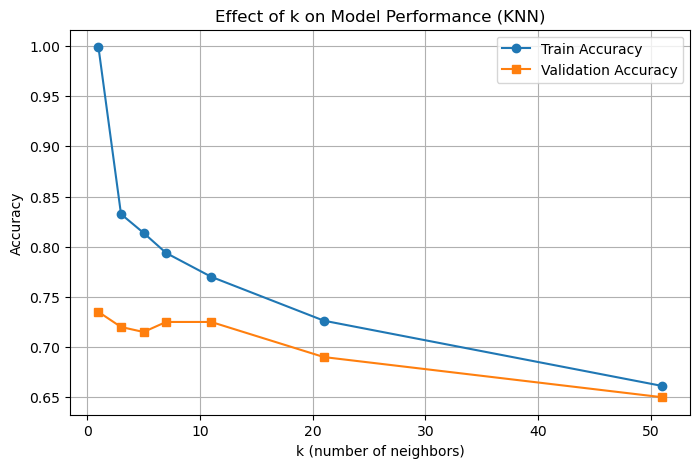

In [75]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(k_values, val_accuracies, marker='s', label='Validation Accuracy')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('Effect of k on Model Performance (KNN)')
plt.legend()
plt.grid(True)
plt.show()
